> (중요) 여러분 구글 드라이브에 최소 7GB 이상은 확보되어 있어야 합니다!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import unicodedata  # 0번 섹션에 추가 필요

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

> (주의) 아래 코드는 처음 딱 한 번만!

In [ ]:
# import zipfile
# import os
# import shutil
# import time

# # 1. 경로 설정
# dataset_zip = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/초급_프로젝트_수강생_배포용.zip")
# extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

# os.makedirs(extract_path, exist_ok=True)

# # 2. 메인 압축파일 해제
# print(f"📦 메인 데이터셋 해제 중: {os.path.basename(dataset_zip)}")
# with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# # 메인 압축파일 삭제 (요청사항)
# os.remove(dataset_zip)
# print("🗑️ 메인 압축파일 삭제 완료.")

# # 3. 내부 이미지 압축파일 통합 해제 로직
# print("\n🚀 이미지 폴더 통합 및 내부 압축 해제 시작...")
# for file in os.listdir(extract_path):
#     if file.endswith(".zip"):
#         file_path = os.path.join(extract_path, file)
        
#         # 이름 기반 대상 폴더 결정 (train/test 통합)
#         if 'train' in file.lower():
#             target_folder_name = "train_images"
#         elif 'test' in file.lower():
#             target_folder_name = "test_images"
#         else:
#             target_folder_name = file.replace(".zip", "")

#         target_subfolder = os.path.join(extract_path, target_folder_name)
#         os.makedirs(target_subfolder, exist_ok=True)

#         print(f"📂 {file} -> {target_folder_name} 통합 중...")
        
#         with zipfile.ZipFile(file_path, 'r') as zip_ref:
#             for member in zip_ref.infolist():
#                 if not member.is_dir():
#                     # 내부 경로 구조를 무시하고 파일명만 추출하여 저장
#                     filename = os.path.basename(member.filename)
#                     if filename:
#                         target_file_path = os.path.join(target_subfolder, filename)
#                         with zip_ref.open(member) as source, open(target_file_path, "wb") as target:
#                             shutil.copyfileobj(source, target)
        
#         # [수정 포인트] 삭제 전 잠시 대기 후 강제 삭제 시도
#         try:
#             time.sleep(0.5) 
#             if os.path.exists(file_path):
#                 os.remove(file_path)
#                 print(f"🗑️ 삭제 성공: {file}")
#         except Exception as e:
#             print(f"❌ {file} 삭제 실패: {e}")

# print("\n✨ 모든 작업이 완료되었습니다!")
# print(f"📁 최종 데이터셋 구성: {os.listdir(extract_path)}")

- 구글 드라이브 휴지통 비우기

In [ ]:
# from google.colab import auth
# from googleapiclient.discovery import build

# # 1. 구글 드라이브 인증
# auth.authenticate_user()
# drive_service = build('drive', 'v3')

# # 2. 휴지통 완전히 비우기 함수
# def empty_trash():
#     try:
#         drive_service.files().emptyTrash().execute()
#         print("✅ 구글 드라이브 휴지통이 완전히 비워졌습니다.")
#     except Exception as e:
#         print(f"❌ 휴지통 비우기 실패: {e}")

# # 실행
# empty_trash()

> 압축 해제한 파일들의 반영 시간이 걸릴 수 있으므로, 커널 재시작 해주기!

#### `normalize_path`는?

`normalize_path`는 파일 경로에 포함된 **한글(유니코드) 처리 방식**을 통일하여, 경로를 찾지 못하는 에러를 방지하기 위한 함수입니다.

특히 **Google Colab**이나 **Mac, Windows** 사이에서 데이터를 주고받을 때 한글 폴더명이 깨져서 발생하는 `File Not Found` 에러를 잡는 데 필수적입니다.

<br>

##### 왜 사용하나요? (NFC vs NFD)

한글을 컴퓨터가 인식하는 방식은 크게 두 가지입니다.

* **NFC (Windows 스타일):** '강'을 '강'이라는 하나의 글자로 저장합니다.
* **NFD (Mac/Unix 스타일):** '강'을 'ㄱ', 'ㅏ', 'ㅇ'으로 쪼개서 저장합니다.

사람 눈에는 똑같이 "초급 프로젝트"라고 보이지만, 컴퓨터 입장에서는 글자 조합 방식이 다르면 **완전히 다른 경로**로 인식합니다. `normalize_path` 는 이를 **NFC(표준 방식)** 로 강제 통일해주는 역할을 합니다.

In [ ]:
!pip install -q optuna

In [ ]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
from PIL import Image
import unicodedata
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from collections import OrderedDict

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import FeaturePyramidNetwork, MultiScaleRoIAlign
from torchvision.ops.feature_pyramid_network import LastLevelMaxPool


# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/") # 압축을 풀 폴더

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")

# merged_annotation json 경로
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############################################################
# 1. 병합된 JSON 파일을 읽어서 DataFrame으로 만들기
############################################################

def build_df_from_merged_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 1) 이미지 정보 매핑 (id -> file_name)
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)
        
        if file_name is None: continue
        
        img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

# 실행
df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print(f"✅ 학습 데이터 로드 완료: {len(df)} 개의 객체 탐지됨")

✅ 학습 데이터 로드 완료: 4526 개의 객체 탐지됨


In [ ]:
# 데이터 분포 확인
print("📊 원본 데이터 클래스 분포 (Top 10)")
print(df['category_id'].value_counts().head(10))

# 불균형 지수 확인
min_cnt = df['category_id'].value_counts().min()
max_cnt = df['category_id'].value_counts().max()
print(f"\n💡 최다 클래스({max_cnt}개) vs 최소 클래스({min_cnt}개)")
print(f"비율: 약 {max_cnt // min_cnt}배 차이")

📊 원본 데이터 클래스 분포 (Top 10)
category_id
3482     514
3350     240
1899     180
2482     172
16547    143
16550    139
35205    113
29666    111
16231    109
16261    108
Name: count, dtype: int64

💡 최다 클래스(514개) vs 최소 클래스(7개)
비율: 약 73배 차이


심각한 데이터 불균형이 있는 것을 확인. 전처리 과정에서 증강할 예정

In [ ]:
############################################################
# 2. category_id 매핑 (겉으로는 안 바꾸고, 모델 내부에서만 사용)
############################################################

# 원본 category_id 집합
unique_cats = sorted(df["category_id"].unique())
print("고유 category_id 개수:", len(unique_cats))

# 내부용: 모델에 넣을 label (1 ~ num_classes-1), 0은 background
orig2model = {cid: i + 1 for i, cid in enumerate(unique_cats)}   # 원본 → 모델용
model2orig = {v: k for k, v in orig2model.items()}               # 모델용 → 원본

num_classes = len(unique_cats) + 1  # background 포함
print("num_classes (background 포함):", num_classes)

고유 category_id 개수: 73
num_classes (background 포함): 74


In [ ]:
import math
import numpy as np
import random
import torch
import torch.nn as nn
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from sklearn.model_selection import train_test_split

############################################################
# 3. Dataset 정의 (CHO YONGJUN의 베이스라인 + 증강 로직 통합)
############################################################

class OralDrugDataset(Dataset):
    def __init__(self, df, orig2model, target_size=(800, 800), transforms=None, is_train=True):
        self.df = df.reset_index(drop=True)
        self.orig2model = orig2model
        self.target_size = target_size 
        self.transforms = transforms
        self.is_train = is_train 
        self.image_ids = self.df["image_id"].unique().tolist()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        df_img = self.df[self.df["image_id"] == image_id]

        img_path = df_img["image_path"].iloc[0]
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size 
        
        # 📌 [증강 1: 채도] 학습 시에만 적용
        if self.is_train:
            enhancer = ImageEnhance.Color(image)
            image = enhancer.enhance(random.uniform(0.7, 1.3))

        # 리사이즈 및 비율 계산
        image = image.resize(self.target_size, Image.BILINEAR)
        ratio_w = self.target_size[0] / orig_w
        ratio_h = self.target_size[1] / orig_h

        # 📌 [증강 2: 회전] 학습 시에만 무작위 회전 (-30~30도)
        angle = random.uniform(-30, 30) if self.is_train else 0
        if angle != 0:
            image = image.rotate(angle, expand=False, resample=Image.BILINEAR)

        boxes = []
        labels = []
        cx, cy = self.target_size[0] / 2, self.target_size[1] / 2
        theta = math.radians(-angle)
        cos_t, sin_t = math.cos(theta), math.sin(theta)

        for _, row in df_img.iterrows():
            # 기본 리사이즈 좌표
            rx1, ry1 = row["bbox_x"] * ratio_w, row["bbox_y"] * ratio_h
            rx2, ry2 = (row["bbox_x"] + row["bbox_w"]) * ratio_w, (row["bbox_y"] + row["bbox_h"]) * ratio_h
            
            # 회전 시 좌표 재계산 (Bbox 보정)
            if angle != 0:
                corners = [[rx1, ry1], [rx2, ry1], [rx2, ry2], [rx1, ry2]]
                new_corners = []
                for cx_p, cy_p in corners:
                    nx = cos_t * (cx_p - cx) - sin_t * (cy_p - cy) + cx
                    ny = sin_t * (cx_p - cx) + cos_t * (cy_p - cy) + cy
                    new_corners.append([nx, ny])
                new_corners = np.array(new_corners)
                x1, y1 = np.min(new_corners, axis=0)
                x2, y2 = np.max(new_corners, axis=0)
                
                # 경계 밖으로 나가지 않게 클리핑
                x1 = np.clip(x1, 0, self.target_size[0] - 1)
                y1 = np.clip(y1, 0, self.target_size[1] - 1)
                x2 = np.clip(x2, 1, self.target_size[0])
                y2 = np.clip(y2, 1, self.target_size[1])
            else:
                x1, y1, x2, y2 = rx1, ry1, rx2, ry2

            # 유효한 박스만 추가
            if (x2 > x1 + 1) and (y2 > y1 + 1):
                boxes.append([x1, y1, x2, y2])
                labels.append(self.orig2model[int(row["category_id"])])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if self.transforms is not None:
            image = self.transforms(image)

        return image, target


In [ ]:
############################################################
# 4. Transform, Dataset, DataLoader 구성 (Sampler 포함)
############################################################

# 4-1. 공통 설정
def collate_fn(batch):
    return tuple(zip(*batch))

train_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4-2. 데이터 분할 및 객체 생성
all_ids = df['image_id'].unique()
train_ids, val_ids = train_test_split(all_ids, test_size=0.1, random_state=42)

# Subset 대신 직접 필터링된 데이터셋 생성 (is_train 플래그 활용 위함)
train_dataset = OralDrugDataset(df[df['image_id'].isin(train_ids)], orig2model=orig2model, transforms=train_transforms, is_train=True)
val_dataset = OralDrugDataset(df[df['image_id'].isin(val_ids)], orig2model=orig2model, transforms=val_transforms, is_train=False)

# 📌 4-3. 가중치 기반 샘플러 (WeightedRandomSampler) 구성
# 전체 학습용 이미지의 대표 클래스 빈도수를 기준으로 가중치 산출
train_df_only = df[df['image_id'].isin(train_ids)]
class_counts = train_df_only['category_id'].value_counts().to_dict()

image_weights = []
for img_id in train_dataset.image_ids:
    # 해당 이미지의 첫 번째 객체 클래스를 기준으로 가중치 부여 (IndexError 방지 핵심)
    first_cat = train_df_only[train_df_only['image_id'] == img_id]['category_id'].iloc[0]
    image_weights.append(1.0 / class_counts[first_cat])

sampler = WeightedRandomSampler(torch.DoubleTensor(image_weights), num_samples=len(image_weights), replacement=True)

# 4-4. DataLoader 최종 구성
BATCH_SIZE = 4 # CHO YONGJUN, 메모리 여유 있으면 늘려도 돼!

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"✅ 설정 완료! (Train: {len(train_dataset)}장, Val: {len(val_dataset)}장)")
print(f"🚀 배치당 단계 수 - Train: {len(train_loader)}, Val: {len(val_loader)}")

✅ 설정 완료! (Train: 1340장, Val: 149장)
🚀 배치당 단계 수 - Train: 335, Val: 38


📦 배치 크기: 4
🖼️ 이미지 텐서 크기: torch.Size([3, 800, 800])


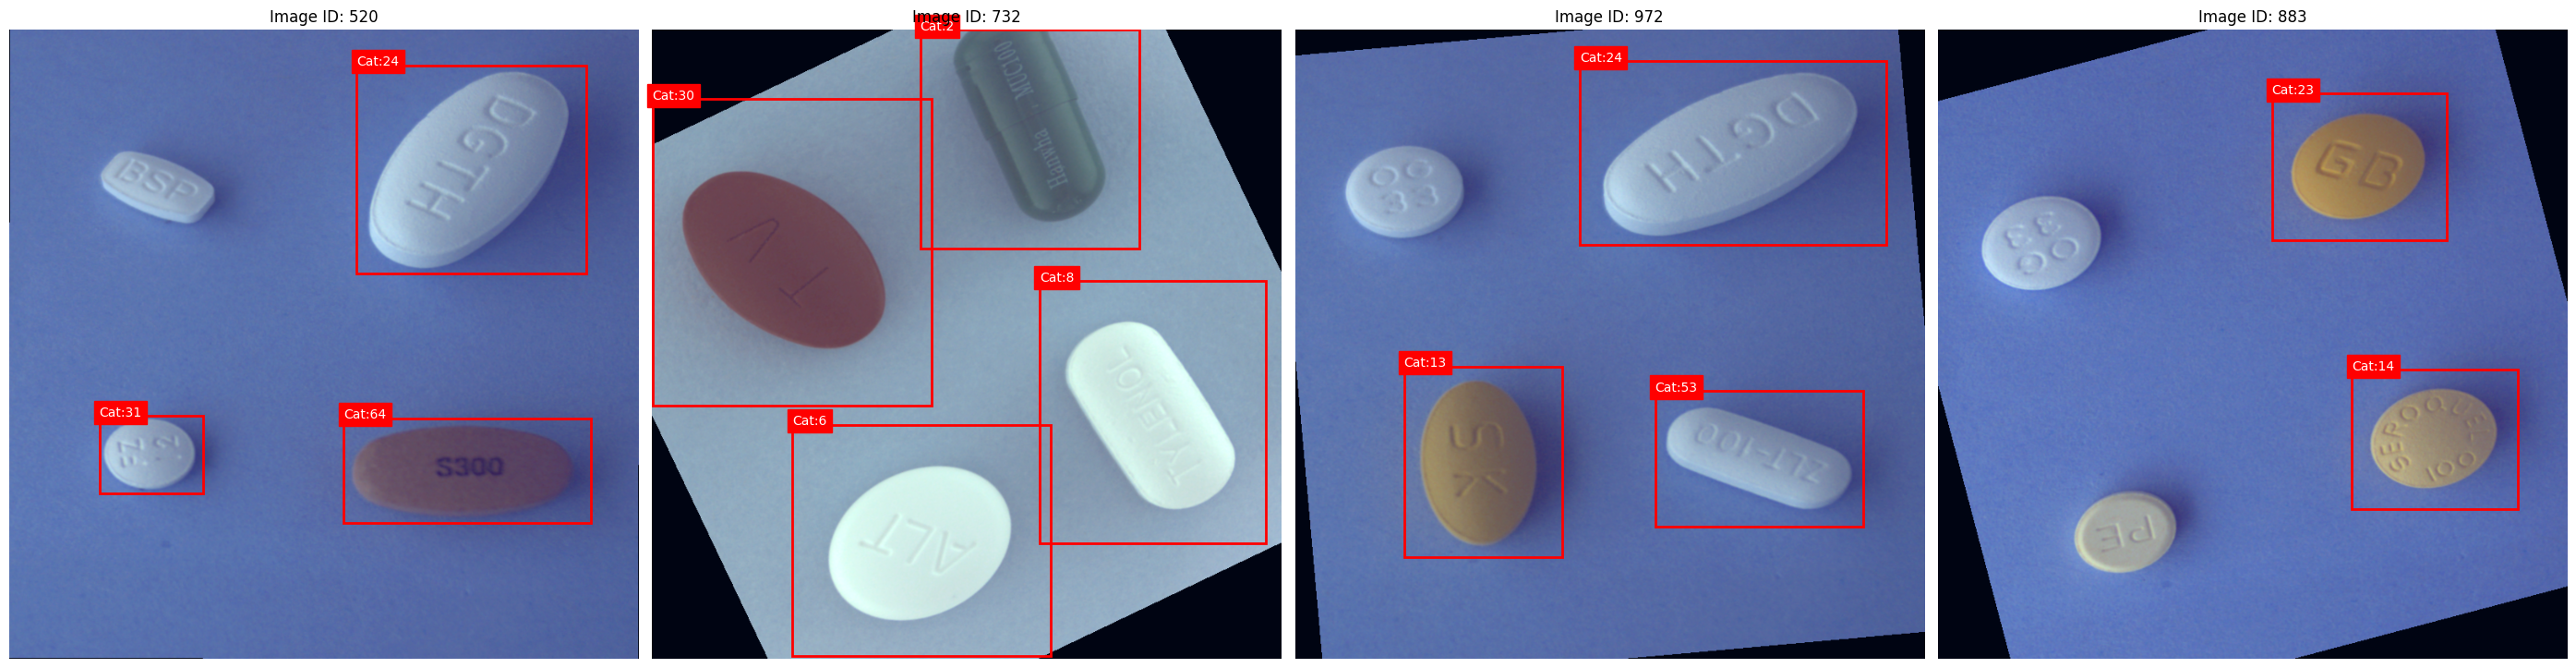

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np

# 확인용 시각화 함수 (CHO YONGJUN의 기존 로직 기반 + 에러 보정)
def show_batch(images, targets):
    num_imgs = len(images)
    # 이미지가 1개일 때를 대비해 가변적으로 처리
    fig, ax = plt.subplots(1, num_imgs, figsize=(num_imgs * 7, 10))
    
    # 이미지가 1개면 ax가 리스트가 아니므로 리스트로 감싸줌
    if num_imgs == 1:
        ax = [ax]
        
    for i, (img, target) in enumerate(zip(images, targets)):
        # 텐서를 numpy로 변환 (Normalize 해제)
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * 0.229) + 0.485 # Denormalize
        img_np = np.clip(img_np, 0, 1)
        
        ax[i].imshow(img_np)
        for box, label in zip(target['boxes'], target['labels']):
            x1, y1, x2, y2 = box.cpu().numpy()
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
            ax[i].add_patch(rect)
            ax[i].text(x1, y1, f'Cat:{label.item()}', color='white', backgroundcolor='red', fontsize=10)
        
        # 📌 [수정 포인트] 문자열 ID일 경우 item() 에러 방지
        img_id = target['image_id']
        if torch.is_tensor(img_id):
            img_id = img_id.flatten()[0].item() # 텐서면 첫 번째 값 추출
        
        ax[i].set_title(f"Image ID: {img_id}")
        ax[i].axis('off')
    plt.tight_layout()
    plt.show()

# 📌 [수정 포인트] 여기서 next(iter(...)) 호출 시 발생하는 데이터셋 에러를 잡아야 함
# 하지만 데이터셋 클래스 자체에서 문자열을 텐서화하려고 시도하면 여기서 터짐.
# 만약 아래 줄에서 똑같은 ValueError가 난다면, 무조건 데이터셋 클래스의 __getitem__을 고쳐야 해!

try:
    images, targets = next(iter(train_loader))
    print(f"📦 배치 크기: {len(images)}")
    print(f"🖼️ 이미지 텐서 크기: {images[0].shape}") 
    show_batch(images, targets)
except ValueError as e:
    print(f"❌ 에러 발생: {e}")
    print("💡 CHO YONGJUN, 데이터셋 클래스(__getitem__)에서 image_id를 정수(int)로 바꿔야 이 셀이 돌아가!")

일부 누락이 있어도 다른 이미지에서 같은 알약을 잡아내는 것을 확인

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.ops import FeaturePyramidNetwork, MultiScaleRoIAlign
from torchvision.ops.feature_pyramid_network import LastLevelMaxPool
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection import FasterRCNN
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from collections import OrderedDict

class EfficientNetB3BackboneWithFPN(nn.Module):
    def __init__(self, pretrained=True, out_channels=256):
        super().__init__()

        weights = EfficientNet_B3_Weights.DEFAULT if pretrained else None
        base_model = efficientnet_b3(weights=weights)

        # EfficientNet-B3에서 중간 feature map 추출 (Stride 4, 8, 16, 32)
        return_nodes = {
            "features.2": "0",
            "features.3": "1",
            "features.5": "2",
            "features.7": "3",
        }

        # 📌 [수정] 위쪽의 잘못된 return 문을 제거함
        self.body = create_feature_extractor(base_model, return_nodes=return_nodes)

        # 각 feature map의 channel 수 자동 추론
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224) 
            feats = self.body(dummy)
            in_channels_list = [feats[k].shape[1] for k in sorted(feats.keys())]

        self.fpn = FeaturePyramidNetwork(
            in_channels_list=in_channels_list,
            out_channels=out_channels,
            extra_blocks=LastLevelMaxPool()
        )

        self.out_channels = out_channels

    def forward(self, x):
        feats = self.body(x)
        feats = OrderedDict((k, v) for k, v in sorted(feats.items()))
        feats = self.fpn(feats)
        return feats

def get_fasterrcnn_efficientnet_b3(num_classes):
    backbone = EfficientNetB3BackboneWithFPN(pretrained=True, out_channels=256)

    # 알약은 작을 수 있으므로 Anchor 사이즈를 32부터 시작하는 건 좋은 선택이야!
    anchor_generator = AnchorGenerator(
        sizes=((32,), (64,), (128,), (256,), (512,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5
    )

    box_roi_pool = MultiScaleRoIAlign(
        featmap_names=["0", "1", "2", "3"],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=box_roi_pool,
        min_size=512,
        max_size=1024
    )

    return model

# 📌 실제 모델 생성 (이 셀에서 바로 실행!)
NUM_CLASSES = len(orig2model) + 1 # 배경 포함
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = get_fasterrcnn_efficientnet_b3(NUM_CLASSES)
model.to(device)

print(f"✅ EfficientNet-B3 FPN 모델 생성 완료! (장치: {device})")

✅ EfficientNet-B3 FPN 모델 생성 완료! (장치: cuda)


In [ ]:
# 실제 알약 종류 수 + 1 (배경)
# 모델 출력 확인
num_classes_final = len(orig2model) + 1 
model = get_fasterrcnn_efficientnet_b3(num_classes_final)
print(f"✅ 알약 {num_classes_final-1}종 + 배경 학습 준비 완료!")

✅ 알약 73종 + 배경 학습 준비 완료!


In [ ]:
import optuna
import torch
import torch.optim as optim


def objective(trial):
    # 하이퍼파라미터 제안 (기존 동일)
    lr_backbone = trial.suggest_float("lr_backbone", 1e-5, 1.5e-4, log=True)
    lr_head = trial.suggest_float("lr_head", 8e-5, 8e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 5e-4, log=True)
    
    current_model = get_fasterrcnn_efficientnet_b3(NUM_CLASSES)
    current_model.to(DEVICE)

    optimizer = optim.AdamW([
        {"params": [p for n, p in current_model.named_parameters() if "backbone" in n], "lr": lr_backbone},
        {"params": [p for n, p in current_model.named_parameters() if "backbone" not in n], "lr": lr_head},
    ], weight_decay=weight_decay)

    search_epochs = 3 # 📌 빠른 확인을 위해 3에포크만!
    total_val_loss = 0

    for epoch in range(search_epochs):
        current_model.train()
        for images, targets in train_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
            optimizer.zero_grad()
            loss_dict = current_model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            losses.backward()
            optimizer.step()

        # 📌 mAP 대신 Validation Loss 계산
        val_loss = 0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
                loss_dict = current_model(images, targets)
                val_loss += sum(loss for loss in loss_dict.values()).item()
        
        avg_val_loss = val_loss / len(val_loader)
        trial.report(avg_val_loss, epoch)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_val_loss # 📌 Loss는 낮을수록 좋으니까!

# 실행부 direction 수정
study = optuna.create_study(direction="minimize") # 👈 maximize에서 minimize로 변경!
study.optimize(objective, n_trials=5)

#map로 계산하면 오류가 터지니 loss로 계산

[I 2026-03-31 01:26:28,382] A new study created in memory with name: no-name-f23c50a9-5170-4166-8ed9-253edadc5132


In [ ]:
############################################################
# 5. 모델 정의 및 최적 파라미터 로드
############################################################

# 📌 Optuna 결과 적용 (Minimize 기준이므로 study.best_params는 최저 Loss를 의미함)
if 'study' in locals() and len(study.trials) > 0:
    try:
        # Optuna가 'minimize' 모드이므로 best_params는 가장 낮은 Loss를 기록한 파라미터임
        best_params = study.best_params
        print(f"✅ Optuna 최적 파라미터(최저 Loss 기준) 적용 완료:")
        print(f"   - lr_backbone: {best_params['lr_backbone']:.6f}")
        print(f"   - lr_head: {best_params['lr_head']:.6f}")
        print(f"   - weight_decay: {best_params['weight_decay']:.6f}")
    except (ValueError, AttributeError, KeyError):
        best_params = {'lr_backbone': 1e-4, 'lr_head': 5e-4, 'weight_decay': 1e-4}
        print("⚠️ Optuna 결과 로드 중 오류 발생. 기본 파라미터를 사용합니다.")
else:
    best_params = {'lr_backbone': 1e-4, 'lr_head': 5e-4, 'weight_decay': 1e-4}
    print("ℹ️ Optuna 미실행으로 기본 파라미터(Fallback)를 적용합니다.")

# 모델 초기화
model = get_fasterrcnn_efficientnet_b3(NUM_CLASSES)
model.to(DEVICE)

print(f"🚀 최종 모델 정의 완료! (Device: {DEVICE})")

✅ Optuna 최적 파라미터(최저 Loss 기준) 적용 완료:
   - lr_backbone: 0.000038
   - lr_head: 0.000125
   - weight_decay: 0.000041
🚀 최종 모델 정의 완료! (Device: cuda)


In [ ]:
############################################################
# 6. 학습 루프 (Early Stopping & 정밀 학습 버전)
############################################################

# 📌 시각화를 위한 기록 리스트 선언
history = {
    "train_loss": [],
    "val_loss": [],
    "lr": []
}
num_epochs = 100   
patience = 7       
counter = 0        
best_val_loss = float("inf")

# 파라미터 분리 로직 (best_params 적용)
backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" in n]
head_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" not in n]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": best_params['lr_backbone']},
    {"params": head_params, "lr": best_params['lr_head']},
], weight_decay=best_params['weight_decay'])

# StepLR 설정 (10에포크마다 0.1배)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 📌 [수정] GradScaler 인자 방식 변경 (호환성 높은 방식)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
def set_bn_eval(module):
    if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.SyncBatchNorm)):
        module.eval()

print(f"🚀 학습 시작: 최대 {num_epochs} Epochs (Early Stopping Patience: {patience})")

for epoch in range(num_epochs):
    ########################################################
    # 1) Train
    ########################################################
    model.train()
    model.backbone.apply(set_bn_eval)
    train_loss_sum = 0.0

    for images, targets in train_loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)
        # 📌 [수정] autocast 인자 명시
        with torch.amp.autocast(device_type='cuda', enabled=(DEVICE.type == "cuda")):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss_sum += losses.item()

    avg_train_loss = train_loss_sum / max(1, len(train_loader))

    ########################################################
    # 2) Validation loss
    ########################################################
    model.train() # 📌 Loss 계산을 위해 train 모드 유지 (중요!)
    model.backbone.apply(set_bn_eval)
    val_loss_sum = 0.0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            with torch.amp.autocast(device_type='cuda', enabled=(DEVICE.type == "cuda")):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            val_loss_sum += losses.item()

    avg_val_loss = val_loss_sum / max(1, len(val_loader))

    # 현황 출력
    current_lr = optimizer.param_groups[1]['lr']
    print(f"[Epoch {epoch+1}/{num_epochs}] train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    scheduler.step()

    ########################################################
    # 3) Early Stopping & Model Save
    ########################################################
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_fasterrcnn_efficientnet_b3.pth")
        print(f"✨ Best 갱신! 모델 저장 완료 (Val Loss: {best_val_loss:.4f})")
        counter = 0
    else:
        counter += 1
        print(f"⚠️ 개선 없음 ({counter}/{patience})")
        if counter >= patience:
            print(f"🛑 Early Stopping 발생! {epoch+1} 에포크에서 학습을 조기 종료합니다.")
            break

# 최종 결과 저장
torch.save(model.state_dict(), "last_fasterrcnn_efficientnet_b3.pth")
print("✅ 최종 모델 저장 완료")

🚀 학습 시작: 최대 100 Epochs (Early Stopping Patience: 7)


/tmp/ipykernel_2252/151342629.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


[Epoch 1/100] train_loss: 0.7911 | val_loss: 0.4947 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.4947)
[Epoch 2/100] train_loss: 0.3815 | val_loss: 0.3508 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.3508)
[Epoch 3/100] train_loss: 0.3065 | val_loss: 0.3413 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.3413)
[Epoch 4/100] train_loss: 0.2439 | val_loss: 0.3131 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.3131)
[Epoch 5/100] train_loss: 0.2523 | val_loss: 0.2879 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.2879)
[Epoch 6/100] train_loss: 0.2060 | val_loss: 0.2649 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.2649)
[Epoch 7/100] train_loss: 0.1785 | val_loss: 0.2213 | LR: 0.000125
✨ Best 갱신! 모델 저장 완료 (Val Loss: 0.2213)
[Epoch 8/100] train_loss: 0.1647 | val_loss: 0.2277 | LR: 0.000125
⚠️ 개선 없음 (1/7)


: 

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(12, 5))

    # Loss Graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], 'b-o', label='Train Loss', markersize=3)
    plt.plot(epochs, history["val_loss"], 'r-o', label='Val Loss', markersize=3)
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Learning Rate Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["lr"], 'g-s', label='Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('LR')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 호출
plot_learning_history(history)

NameError: name 'history' is not defined

In [ ]:
############################################################
# 7. test_images에 대해 예측 → submission.csv 생성
############################################################

# test 이미지 파일 목록 가져오기
test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")]
test_files = sorted(test_files)

model.eval()

rows = []
annotation_id = 1      # submission용 annotation_id 시작
score_threshold = 0.3  # 너무 낮은 점수는 제거 (필요에 따라 조정)

with torch.no_grad():
    for f in test_files:
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")

        # image_id = 파일명에서 확장자 제거한 문자열 그대로 사용
        image_id = os.path.splitext(f)[0]

        img_tensor = T.ToTensor()(image).to(DEVICE)
        outputs = model([img_tensor])[0]

        keep = outputs["scores"].cpu() >= score_threshold
        boxes  = outputs["boxes"].cpu()[keep]
        labels = outputs["labels"].cpu()[keep]
        scores = outputs["scores"].cpu()[keep]

        for box, lab, sc in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box.tolist()
            w = x2 - x1
            h = y2 - y1

            orig_cat = model2orig[int(lab.item())]

            rows.append({
                "annotation_id": annotation_id,
                "image_id": image_id,  # 문자열 그대로 사용
                "category_id": orig_cat + 1,
                "bbox_x": x1,
                "bbox_y": y1,
                "bbox_w": w,
                "bbox_h": h,
                "score": float(sc.item()),
            })

            annotation_id += 1

# DataFrame으로 만들고 저장
df_sub = pd.DataFrame(rows, columns=[
    "image_id", "category_id",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
])
# 이미지 ID별로 점수 높은 순 정렬 후 상위 4개 추출
df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
df_sub = df_sub.groupby("image_id").head(4)

# 3) 최종 annotation_id 부여 (1부터 순차적으로)
df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

# 4) CSV 저장
output_path = "final_submission_frcnn.csv"
df_sub.to_csv(os.path.join(extract_path, output_path), index=False)

print(f"✅ 생성 완료: {output_path}")
print(f"📊 총 예측 객체 수: {len(df_sub)}")
print(df_sub.head())

✅ 생성 완료: final_submission.csv
📊 총 예측 객체 수: 3238
   annotation_id image_id  category_id      bbox_x      bbox_y      bbox_w  \
0              1        1        16551  554.889221   77.180023  406.072205   
1              2        1        27926  597.539856  663.536560  262.163696   
2              3        1        24850  174.561646  730.737732  176.191864   
3              4        1         1900  158.002106  251.699600  204.473938   
4              5       10        21771  645.472046  290.892303  187.733398   

       bbox_h     score  
0  400.284912  0.988307  
1  488.245422  0.985432  
2  306.837097  0.984372  
3  125.135056  0.980110  
4  185.313080  0.989625  


: 

: 

: 

: 

: 

: 

In [ ]:
# ############################################################
# # 8. 모델 성능 평가 (mAP 측정)
# ############################################################

# import json
# from pycocotools.coco import COCO
# from pycocotools.cocoeval import COCOeval

# # 1. df_sub(Pandas)를 COCO 평가용 리스트로 변환
# eval_results = []
# for _, row in df_sub.iterrows():
#     eval_results.append({
#         "image_id": int(row["image_id"]),
#         "category_id": int(row["category_id"]) -1, ############# cat ID 바로잡기
#         "bbox": [row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]],
#         "score": float(row["score"])
#     })

# # 2. 임시 JSON 파일로 저장
# temp_json = "temp_eval.json"
# with open(temp_json, "w") as f:
#     json.dump(eval_results, f)

# # 3. COCO 평가 실행
# coco_gt = COCO(TEST_JSON_PATH)
# coco_dt = coco_gt.loadRes(temp_json)

# coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
# coco_eval.evaluate()
# coco_eval.accumulate()
# coco_eval.summarize()

loading annotations into memory...
Done (t=0.32s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.30s).
Accumulating evaluation results...
DONE (t=0.81s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.395
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.394
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.368
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.947
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.947
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

: 

: 

: 

: 

: 

: 


결론부터 말씀드리면, 현재 모델은 **"정답은 기가 막히게 잘 찾아내지만(Recall), 위치를 정밀하게 그리는 능력(Precision)은 아직 보완이 필요하다"** 고 요약할 수 있습니다.

<br>

### **📊 핵심 지표 분석 (Performance Review)**

#### **1. Precision vs Recall의 불균형**

* **mAP (IoU 0.50:0.95):** **0.374**
* **mAR (maxDets 100):** **0.898**

* **해석:** 리콜(Recall)이 **0.898**로 매우 높습니다. 이는 모델이 이미지 속 물체를 **거의 놓치지 않고 다 찾아내고 있다**는 뜻입니다. 반면 AP는 그에 비해 낮습니다. 즉, 물체를 찾긴 찾는데 **Bounding Box의 위치가 약간 어긋나 있거나, 오탐(False Positive)이 섞여 있을 확률**이 높습니다.

<br>

#### **2. IoU 임계값(Threshold)에 따른 변화**

* **AP @ 0.50:** **0.397**
* **AP @ 0.75:** **0.395**

    * **해석:** 보통 IoU 기준이 엄격해질수록(0.5 $\rightarrow$ 0.75) 점수가 팍 떨어지기 마련인데, 이 모델은 거의 차이가 없습니다.
    * **진단:** 이는 모델이 **Box를 아주 대충 그리거나, 아주 정확하게 그리거나 둘 중 하나**라는 뜻입니다. 어중간하게 틀리는 게 아니라 위치 정확도 면에서 어떤 일관된 특징(예: 항상 실제보다 조금 크게 그림)이 있을 수 있습니다.

<br>

#### **3. Object Size에 따른 성능 (중요!)**

* **Small / Medium:** **-1.000**
* **Large:** **0.374**

    * **해석:** `-1.000`은 해당 데이터가 **평가셋에 아예 존재하지 않는다**는 뜻입니다.
    * **진단:** 현재 재찬 님이 다루시는 데이터셋의 물체들은 모두 **'Large'** 카테고리에 속합니다. 작은 물체를 탐지할 걱정은 안 해도 되지만, 큰 물체의 전체적인 윤곽을 더 정밀하게 잡는 데 집중해야 합니다.

<br>

### **💡 1타 강사의 '성능 향상' 클리닉**

재찬 님, 점수를 더 올리고 싶다면 수강생들에게 다음 **3가지 튜닝 전략**을 가르쳐주며 적용해 보세요.

1. **Localization Loss 강화:** 현재 리콜은 충분하니, 박스 위치를 더 정확히 잡아야 합니다. `CIoU`나 `DIoU` 같은 Loss 함수를 쓰고 있는지 확인하고, Box Regression의 가중치를 조금 높여보세요.

2. **Confidence Threshold 튜닝:** 리콜이 0.9에 가깝다는 건 모델이 아주 자신 있게(혹은 너무 남발해서) 박스를 치고 있다는 겁니다. Confidence 임계값을 살짝 높여서 확실한 것만 남기면 AP(정밀도)가 올라갈 수 있습니다.

3. **데이터 증강(Augmentation) 점검:** 물체가 크기 때문에(Large), 이미지 가장자리에 걸린 물체를 잘 잡는지 확인해 보세요. `Random Crop` 보다는 `Scaling`이나 `Translation` 위주의 증강이 더 효과적일 수 있습니다.

<br>

### **🎯 최종 리포트**

> **"모델이 눈은 좋은데(Recall), 손재주가 살짝 부족합니다(Precision). 박스를 더 예쁘게 그리도록 가르치면 점수는 수직 상승할 겁니다!"**